In [3]:
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn

In [4]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
classes = ["Burn", "Cut", "Bruise", "Normal"]

print("Classes for the model:")
print(classes)

Classes for the model:
['Burn', 'Cut', 'Bruise', 'Normal']


In [6]:
!unzip /dataset.zip

Archive:  /dataset.zip
replace dataset/Bruise/bruises (1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: dataset/Bruise/bruises (1).jpg  
replace dataset/Bruise/bruises (10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace dataset/Bruise/bruises (10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: dataset/Bruise/bruises (10).jpg  
  inflating: dataset/Bruise/bruises (100).jpg  
  inflating: dataset/Bruise/bruises (101).jpg  
  inflating: dataset/Bruise/bruises (102).jpg  
  inflating: dataset/Bruise/bruises (103).jpg  
  inflating: dataset/Bruise/bruises (104).jpg  
  inflating: dataset/Bruise/bruises (105).jpg  
  inflating: dataset/Bruise/bruises (106).jpg  
  inflating: dataset/Bruise/bruises (107).jpg  
  inflating: dataset/Bruise/bruises (108).jpg  
  inflating: dataset/Bruise/bruises (109).jpg  
  inflating: dataset/Bruise/bruises (11).jpg  
  inflating: dataset/Bruise/bruises (110).jpg  
  inflating: dataset/Bruise/bruises (1

In [7]:
data = []
labels = []

img_size = 128
dataset_path = "dataset"

for category in classes:
    folder = os.path.join(dataset_path, category)
    label = classes.index(category)

    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path)
        image = cv2.resize(image, (img_size, img_size))

        data.append(image)
        labels.append(label)

data = np.array(data) / 255.0
labels = np.array(labels)

print("Dataset Loaded Successfully")
print("Total Images:", len(data))

Dataset Loaded Successfully
Total Images: 266


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 212
Testing images: 54


In [9]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dense(4, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 621ms/step - accuracy: 0.2877 - loss: 2.9227 - val_accuracy: 0.1296 - val_loss: 1.5068
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3491 - loss: 1.3300 - val_accuracy: 0.5000 - val_loss: 1.1608
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4434 - loss: 1.1336 - val_accuracy: 0.5370 - val_loss: 1.0699
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5142 - loss: 1.0169 - val_accuracy: 0.4815 - val_loss: 1.0322
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6415 - loss: 0.8055 - val_accuracy: 0.4815 - val_loss: 1.4871
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7406 - loss: 0.6637 - val_accuracy: 0.5556 - val_loss: 1.0910
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8632 - loss: 0.4471 - val_accuracy: 0.5556 - val_loss: 1.3290
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8538 - loss: 0.3815 - val_accuracy: 0.4444 - val_loss: 1.5135

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Model Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5556 - loss: 1.5305
Final Model Accuracy: 0.5555555820465088


In [12]:
first_aid = {
    "Burn": "Cool the burn under running water for 10 minutes and cover with sterile bandage.",
    "Cut": "Clean the wound with water, apply antiseptic, and cover with bandage.",
    "Bruise": "Apply cold compress to reduce swelling.",
    "Normal": "No injury detected."
}

In [13]:
def visual_aid_system(image_path):

    img = cv2.imread(image_path)
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (128,128))
    img = np.array(img) / 255.0
    img = img.reshape(1,128,128,3)

    prediction = model.predict(img)
    index = np.argmax(prediction)

    injury = classes[index]

    plt.imshow(img_display)
    plt.title("Detected: " + injury)
    plt.axis('off')
    plt.show()

    print("Detected Injury:", injury)
    print("First Aid Advice:", first_aid[injury])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step


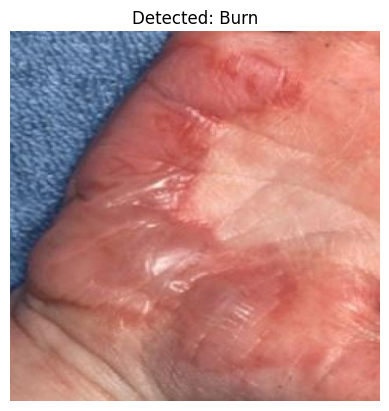

Detected Injury: Burn
First Aid Advice: Cool the burn under running water for 10 minutes and cover with sterile bandage.


In [14]:
visual_aid_system("/burns (4).jpg")

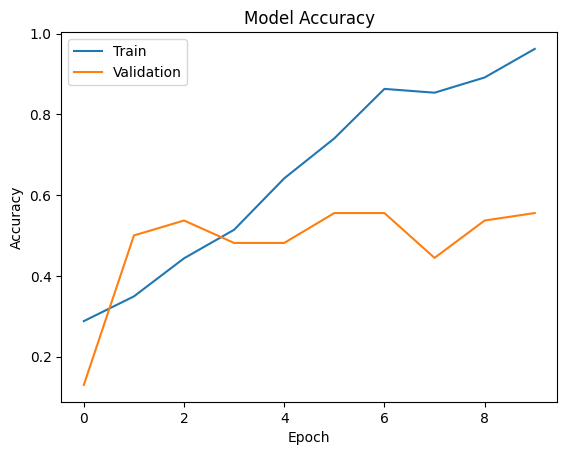

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()